## CVE Vulnerability Data Analysis

### Target Audience
- Software Vendors  
- SOC (Security Operations Center) Analysts  
- State-Sponsored Cyber Agencies  
- Security Researchers  

### Dataset
**MITRE Corporation CVE Records (2000–2019)**

---

### Background
Cybersecurity vulnerabilities are increasing rapidly, with tens of thousands of new CVEs recorded each year.

While many vulnerabilities are patched, a significant portion remain unpatched and continue to be actively exploited. This creates ongoing risk for both vendors and users—especially because the CVE dataset is fully public.

---

### Purpose of the Analysis
This project analyzes the CVE dataset to identify patterns and highlight important risk factors.

**Goals:**
- Understand how vulnerabilities evolve over time  
- Identify high-risk vulnerabilities  
- Recognize common weakness types (CWE) to prioritize patching  
- Support improved security practices  

---

### Key Concepts and Definitions

- **CVE (Common Vulnerabilities and Exposures):**  
  A publicly disclosed catalog of cybersecurity vulnerabilities  

- **CVSS Score (0–10):**  
  Measures vulnerability severity  
  - 0.0–3.9 → Low  
  - 4.0–6.9 → Medium  
  - 7.0–8.9 → High  
  - 9.0–10.0 → Critical  

- **CWE (Common Weakness Enumeration):**  
  A standardized classification of vulnerability types in software and hardware  
  - Example: **CWE-79** → Cross-Site Scripting (XSS)  

- **Published Date (`pub_date`):**  
  The timestamp when the vulnerability was publicly disclosed  

---

### TL;DR
- **CWE** → Type of weakness  
- **CVSS** → Severity  
- **pub_date** → Disclosure date  
- **summary** → Human-made explanation  

1) ## Import the Python Libraries and Dataset
What is needed: <br>
* <u>Import pandas and matplotlib</u> for .csv handling and data visualization
* Use pandas to <u>open the full CVE.csv</u>
* Test the opening of the CVE.csv by <u>printing some raw data</u>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

#Dataset Import:
df = pd.read_csv("cve.csv")

#Test the Dataset by Outputting Some Raw Data:
print(df.head())

       Unnamed: 0             mod_date             pub_date  cvss  cwe_code  \
0  CVE-2019-16548  2019-11-21 15:15:00  2019-11-21 15:15:00   6.8       352   
1  CVE-2019-16547  2019-11-21 15:15:00  2019-11-21 15:15:00   4.0       732   
2  CVE-2019-16546  2019-11-21 15:15:00  2019-11-21 15:15:00   4.3       639   
3   CVE-2013-2092  2019-11-20 21:22:00  2019-11-20 21:15:00   4.3        79   
4   CVE-2013-2091  2019-11-20 20:15:00  2019-11-20 20:15:00   7.5        89   

                                            cwe_name  \
0                  Cross-Site Request Forgery (CSRF)   
1   Incorrect Permission Assignment for Critical ...   
2   Authorization Bypass Through User-Controlled Key   
3   Improper Neutralization of Input During Web P...   
4   Improper Neutralization of Special Elements u...   

                                             summary access_authentication  \
0  A cross-site request forgery vulnerability in ...                   NaN   
1  Missing permission checks in 

2) ## Clean Up the Data
What is needed: <br>
* Remove rows with <u>missing data</u>
* Check that <u>CVSS values are numbers</u> and within the acceptable range
* <u>Save</u> all rows that meet the requirements to a <u>new .csv</u>

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

#Dataset Import:
df = pd.read_csv("cve.csv")

#Remove Any Rows With Any Empty Cells:
df = df.dropna()

#Ensure That all CVSS Values are Numerical:
df["cvss"] = pd.to_numeric(df["cvss"])

#Remove Rows Where CVSS is < 0 or > 10 (the range of the CVSS rating):
df = df[(df["cvss"] >=0) & (df["cvss"] <= 10)]

#Save the Data to a New Cleaned Dataset:
df.to_csv("cleaned_cve.csv", index=False)


3) ## Create a Year Created Column
What is needed: <br>
* <u>Create column</u> from <u>year value of **pub_date** column</u>
* <u>Remove</u> all <u>rows</u> with <u>no year</u> column
* <u>Make</u> it an <u>integer</u>

In [0]:
# Cleaned Dataset Import:
df = pd.read_csv("cleaned_cve.csv")

# Year Column
df["year"] = pd.to_datetime(df["pub_date"], errors="coerce").dt.year
df = df.dropna(subset=["year"])
df["year"] = df["year"].astype(int)

4) ## Collect Filters by User Input
What is needed: <br>
* Collect filters by:
    * Year
    * CVSS Range
    * Vendor
    * CWE Code
    * CWE Name
* <u>Ask user for input</u> for each

In [9]:
# Year Range Filtering:
year_min = input("Enter minimum year (or Enter to skip): ")
year_max = input("Enter maximum year (or Enter to skip): ")

# CVSS Range Filtering:
cvss_min = input("Enter minimum CVSS score (or Enter to skip): ")
cvss_max = input("Enter maximum CVSS score (or Enter to skip): ")

# Vendor Keyword Search:
vendor = input("Enter vendor name (or press Enter to skip): ").lower()

# CWE Code Search:
cwe_code = input("Enter CWE code (or press Enter to skip): ")

# CWE Name Search:
cwe_name = input("Enter CWE name (or press Enter to skip): ").lower()

Enter minimum year (or Enter to skip):  
Enter maximum year (or Enter to skip):  
Enter minimum CVSS score (or Enter to skip):  
Enter maximum CVSS score (or Enter to skip):  
Enter vendor name (or press Enter to skip):  
Enter CWE code (or press Enter to skip):  
Enter CWE name (or press Enter to skip):  


5) ## Filter by Previous User Input
What is needed: <br>
* <u>Apply filters</u> to dataset based on previously collected <u>user input</u>
* Filter by (if existent):
    * Year minimum
    * Year maximum
    * CVSS minimum
    * CVSS maximum
    * Vendor
    * CWE code
    * CWE name
* <u>Save</u> to <u>new .csv</u>
* Print number of new rows

In [11]:
# Setup For Filtering:
filtered_df = df.copy()

# YEAR FILTER
year_min = int(year_min) if year_min.strip() != "" else None
year_max = int(year_max) if year_max.strip() != "" else None

if year_min is not None:
    filtered_df = filtered_df[filtered_df["year"] >= year_min]

if year_max is not None:
    filtered_df = filtered_df[filtered_df["year"] <= year_max]

# CVSS FILTER
if cvss_min.strip() != "":
    filtered_df = filtered_df[filtered_df["cvss"] >= float(cvss_min)]

if cvss_max.strip() != "":
    filtered_df = filtered_df[filtered_df["cvss"] <= float(cvss_max)]

# VENDOR FILTER
if vendor:
    filtered_df = filtered_df[
        filtered_df["summary"].str.lower().str.contains(vendor, na=False)]

# CWE CODE FILTER
if cwe_code:
    filtered_df = filtered_df[filtered_df["cwe_code"] == cwe_code]

# CWE NAME FILTER
if cwe_name:
    filtered_df = filtered_df[
        filtered_df["cwe_name"].str.lower().str.contains(cwe_name, na=False)]

# Save the Filtered File:
filtered_df.to_csv("filtered_cve.csv", index=False)

print("Rows remaining:", len(filtered_df))

Rows remaining: 88776


6) ## Create a Graph Showing New CVEs Per Year
What is needed: <br>
* <u>Filter data</u> for <u>graphing</u> to just rows with <u>user selected years</u>
* <u>Count CVEs</u> per year
* <u>Plot</u> CVEs over Years

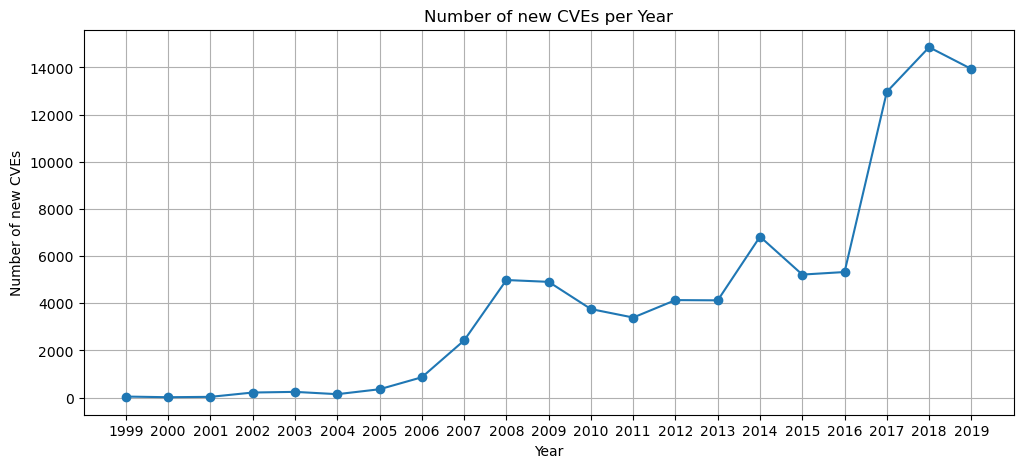

In [12]:
#Filtered Dataset Import:
df = pd.read_csv("filtered_cve.csv")

#Ensure Dates Exist:
df["pub_date"] = pd.to_datetime(df["pub_date"], errors="coerce")
df["year"] = df["pub_date"].dt.year

#Ensure Data is Correct Format
if year_min:
    year_min = int(year_min)
else:
    year_min = df["year"].min()
if year_max:
    year_max = int(year_max)
else:
    year_max = df["year"].max()

#Filter for the year range
df = df[(df["year"] >= year_min) & (df["year"] <= year_max)]

#Count the CVEs
cve_num = df.groupby("year").size()

#GRAPH IT!!!
plt.figure(figsize=(12, 5))
plt.plot(cve_num.index, cve_num.values, marker="o")
plt.title("Number of new CVEs per Year")
plt.xlabel("Year")
plt.ylabel("Number of new CVEs")
plt.xticks(list(cve_num.index))
plt.grid(True)
plt.show()

7) ## Create a bar chart showing Distribution of Severity Levels
What is needed: <br>
* <u>Convert numerical scores to string scores</u>
* <u>Create severity column</u>
* <u>Count CVEs</u> per severity level
* <u>Order</u> the severity levels from least to most
* <u>Plot</u> CVEs per Severity Level

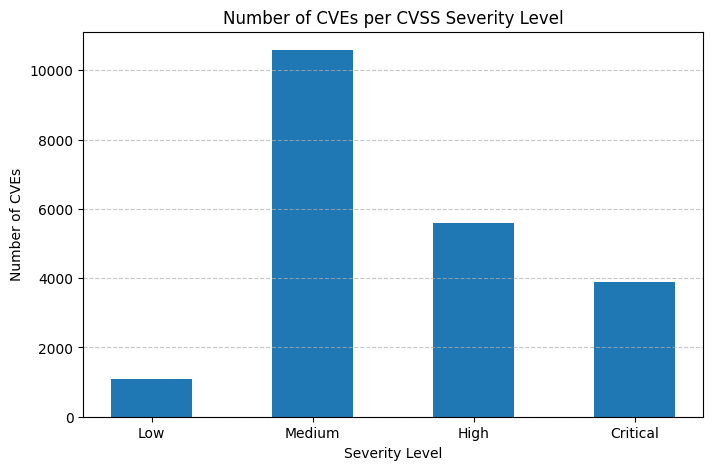

In [41]:
# Load Dataset
df = pd.read_csv("filtered_cve.csv")

# Ensure CVSS is numeric
df["cvss"] = pd.to_numeric(df["cvss"], errors="coerce")

# Remove Invalid Rows
df = df.dropna(subset=["cvss"])

#Define a function that decides severity levels
def cvss_level(score):
    if 0.0 <= score <= 3.9:
        return "Low"
    elif 4.0 <= score <= 6.9:
        return "Medium"
    elif 7.0 <= score <= 8.9:
        return "High"
    elif 9.0 <= score <= 10.0:
        return "Critical"
    else:
        return "Unknown"

#Creates the new severity level column
df["severity"] = df["cvss"].apply(cvss_level)

#Remove Unknown ones
df = df[df["severity"] != "Unknown"]

#Counts how many CVEs per severity level
counts = df["severity"].value_counts()

#Ensure correct display order
order = ["Low", "Medium", "High", "Critical"]
counts = counts.reindex(order).fillna(0)

#PLOT IT!!!
plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values, width=0.5)
plt.title("Number of CVEs per CVSS Severity Level")
plt.xlabel("Severity Level")
plt.ylabel("Number of CVEs")
plt.grid(axis="y",linestyle="--", alpha=0.7)
plt.show()

8) ## Create a Boxplot Showing CVSS Score Distribution by CWE Code
What is needed: <br>
* <u>Ensure CVSS values are numerical</u> and remove any invalid values
* <u>Allow</u> as much <U>user input</u> as the user wants to input
* Show top 10 CWE codes by default
* Group <u>CVSS scores per CWE code</u>
* <u>Plot</u> CVSS Score Distributions Using a Boxplot for Each CWE Code

In [1]:
#Dataset Import
df = pd.read_csv("filtered_cve.csv")

#Clean It
df["cvss"] = pd.to_numeric(df["cvss"], errors="coerce")
df = df.dropna(subset=["cvss", "cwe_code"])

#Make Codes a String
df["cwe_code"] = df["cwe_code"].astype(str).str.strip()

cwe_list = []

print("Enter CWE codes one by one (press Enter to finish):")

#Loop for User Input
while True:
    cwe = input("CWE code: ").strip()
    if cwe == "":
        break
    cwe_list.append(cwe)

#Defaults if no Input Given
if len(cwe_list) == 0:
    cwe_list = df["cwe_code"].value_counts().head(10).index.tolist()

#FILTER IT
filtered = df[df["cwe_code"].isin(cwe_list)]

data = []
valid_cwes = []

#Find the CVSS Scores
for cwe in cwe_list:
    group = filtered[filtered["cwe_code"] == cwe]["cvss"]
    if len(group) > 0:
        data.append(group)
        valid_cwes.append(cwe)

cwe_list = valid_cwes

if len(data) == 0:
    print("No matching CWE codes found in dataset.")
    
#PLOT IT!!!
else:
    plt.figure(figsize=(12, 6))
    plt.boxplot(data, tick_labels=cwe_list)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.xlabel("CWE Code")
    plt.ylabel("CVSS Score")
    plt.show()

9) ## Create a Line Graph Showing CVE Severity Trends Over Time
What is needed: <br>
* Ensure the <u>Severity Column</u> exists
* <u>Group data</u> by year and severity
* <u>Count CVEs</u> for each severity for each year
* Replace unknown values with 0


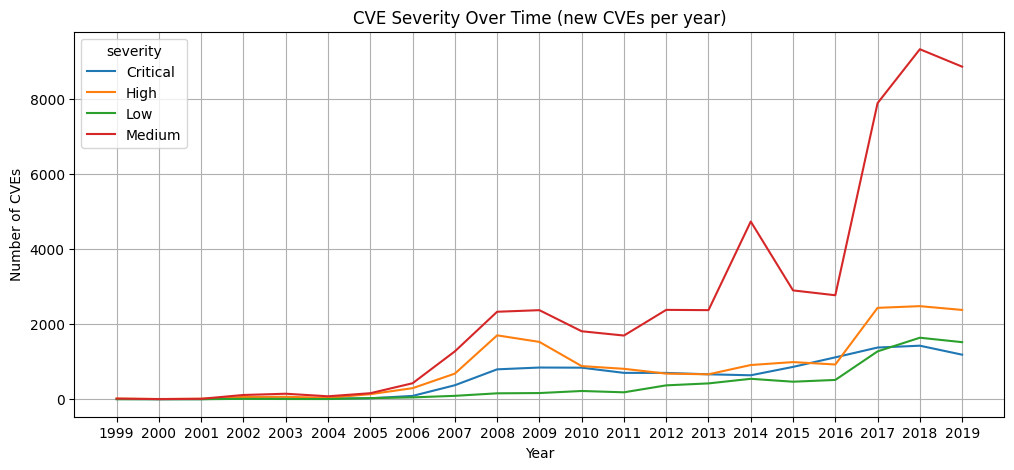

In [65]:
# Load Dataset
df = pd.read_csv("filtered_cve.csv")

# Ensure severity column exists
df["severity"] = df["cvss"].apply(cvss_level)

# Group by year + severity
severity_year = df.groupby(["year", "severity"]).size().().fillna(0)

#PLOT IT!!!
severity_year.plot(figsize=(12, 5))
plt.title("CVE Severity Over Time (new CVEs per year)")
plt.xlabel("Year")
plt.ylabel("Number of CVEs")
plt.grid(True)
plt.xticks(severity_year.index)
plt.show()

# Conclusion and Final Review

## Conclusion

This project successfully analysed CVE vulnerability data using pandas and matplotlib in order to identify cybersecurity trends and high risk vulnerabilities.

Through filtering, cleaning, grouping, and graphing the dataset, the notebook was able to display useful patterns such as:
- The increase in vulnerabilities over time
- The distribution of severity levels
- The relationship between CWE types and CVSS scores

The project achieved its main goal of improving understanding of vulnerability data in a format that is both readable and useful for cybersecurity analysis.

## Final Review

The notebook successfully allowed users to:
- Filter vulnerability data based on multiple conditions
- Visualise cybersecurity trends using graphs
- Identify common weakness types and high severity vulnerabilities
- Understand how CVEs evolve over time

The use of pandas made the dataset easier to clean, organise, and filter, while matplotlib allowed the information to be displayed visually in a clear and understandable way.

## Future Improvements

Potential future improvements for this project could include:
- Interactive graphs and dashboards
- Larger or more recent datasets
- Real time CVE feeds
- More advanced filtering systems
- Additional cybersecurity statistics and analysis

## TL;DR

- Pandas was used for filtering and cleaning the dataset
- Matplotlib was used for graphing and visualisation
- The project identified trends in CVEs, CWE types, and CVSS severity levels
- Multiple graphs were created to improve readability and analysis